# Determinants

A computational companion to [Determinants](https://fjhickernell.github.io/MATH332Fall2026/slides/04-determinants.html), Lecture 04 of MATH 332. Use the deck for the mathematical development; use this notebook to predict, compute, and interpret examples.

We will transform squares, track row operations, recover determinants from PLU factors, and investigate what floating-point determinant values can and cannot tell us. SymPy gives exact arithmetic; NumPy and SciPy give numerical computation; Matplotlib makes the geometry visible.

## Running this notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH332Fall2026/blob/main/notebooks/demonstrations/04-determinants.ipynb)

Run all cells in order with the **qmcpy** Jupyter kernel. The setup cell does nothing to your environment outside Colab. In Colab, it installs the course's recorded `classlib` checkout without changing the working directory. Colab does not save changes back to the course repository; save a copy in Drive to keep your experiments.

**Working habit:** predict the sign and magnitude before running a computation. The determinant can be negative; its absolute value cannot.

In [1]:
from pathlib import Path
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib; this may take a minute …")
    course_checkout = Path("/content/MATH332Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH332Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "submodule", "update", "--init", "--recursive", "classlib",
        ],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", str(course_checkout / "classlib")],
        check=True,
    )
    print("Colab setup complete.")

In [2]:
import numpy as np
import sympy as sp
from sympy import Matrix
from scipy.linalg import lu, lu_factor
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import classlib as cl
from classlib.nbviz import show_mat

%matplotlib inline
cl.nbviz.init(use_tex=False)
sp.init_printing()
np.set_printoptions(precision=6, suppress=True)

## 1. Separate area scaling from orientation

The square's vertices below are **columns**, ordered counterclockwise. Multiplication by $\mathsf{A}$ transforms each vertex. The red and blue arrows follow the first and second columns of $\mathsf{A}$, respectively; keep their order when comparing orientation.

Predict which examples preserve orientation, reverse it, or collapse the square. Two transformations can have equal $|\det(\mathsf{A})|$ and opposite determinant signs.

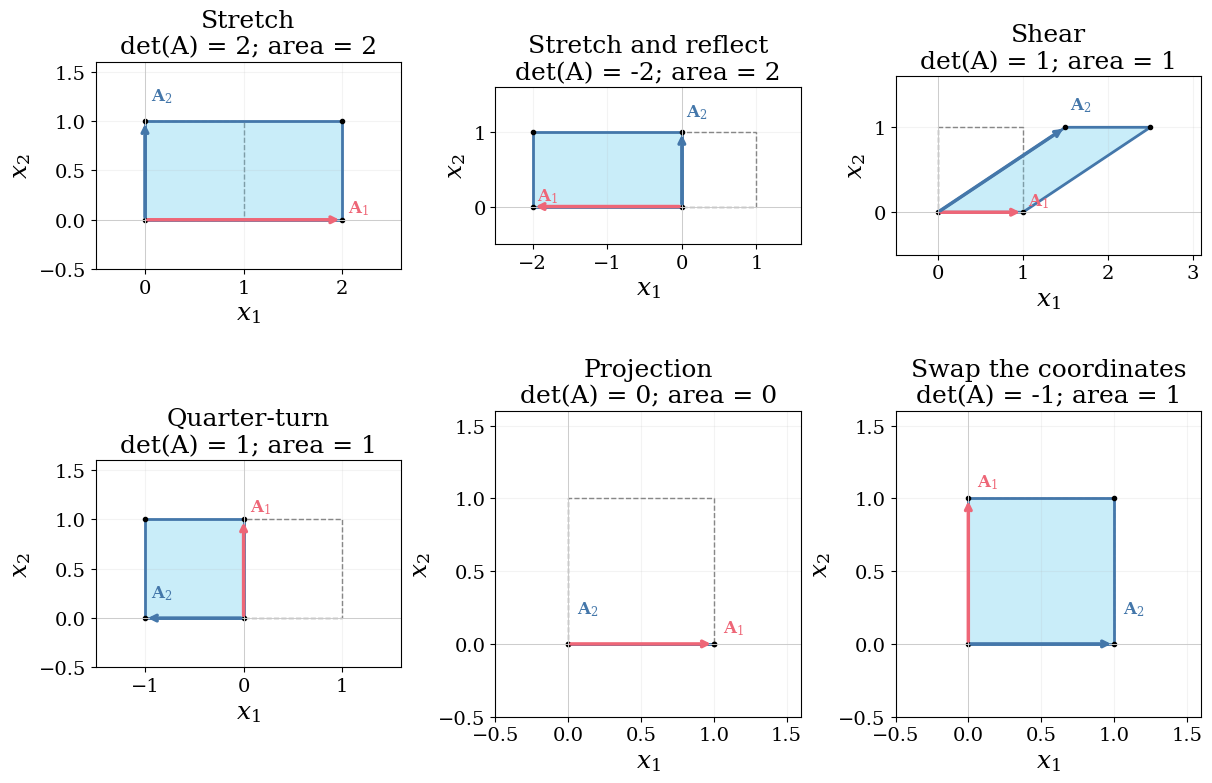

Red arrow: first column; blue arrow: second column.
Dashed outline: original unit square. Filled region: transformed square.
A collapsed square has zero area and no two-dimensional orientation.


In [3]:
square = np.array([[0., 1., 1., 0.], [0., 0., 1., 1.]])

def signed_polygon_area(vertices):
    """Signed shoelace area for vertices stored as ordered columns."""
    x, y = vertices
    return 0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))

def plot_area_action(A, title, ax):
    A = np.asarray(A, dtype=float)
    vertices = A @ square
    determinant = float(np.linalg.det(A))
    signed_area = signed_polygon_area(vertices)
    ax.add_patch(Polygon(square.T, closed=True, fill=False,
                         edgecolor='0.5', linestyle='--', label='Unit square'))
    ax.add_patch(Polygon(vertices.T, closed=True, facecolor='#66CCEE',
                         alpha=0.35, edgecolor='#4477AA'))
    closed = np.column_stack((vertices, vertices[:, 0]))
    ax.plot(*closed, color='#4477AA', linewidth=2)
    for j, color in enumerate(['#EE6677', '#4477AA']):
        ax.annotate('', xy=A[:, j], xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
        ax.text(*(A[:, j] + np.array([0.06, 0.08 + 0.13*j])),
                rf'$\mathbf{{A}}_{j+1}$', color=color, fontsize=12)
    for j, vertex in enumerate(vertices.T):
        ax.plot(*vertex, 'o', color='black', markersize=3)
    all_points = np.column_stack((square, vertices))
    lower, upper = all_points.min(axis=1)-0.5, all_points.max(axis=1)+0.6
    ax.set_xlim(lower[0], upper[0])
    ax.set_ylim(lower[1], upper[1])
    ax.axhline(0, color='0.8', lw=0.7)
    ax.axvline(0, color='0.8', lw=0.7)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'{title}\ndet(A) = {determinant:.3g}; area = {abs(signed_area):.3g}')
    ax.grid(alpha=0.15)
    assert np.isclose(signed_area, determinant)

geometric_examples = {
    'Stretch': np.diag([2., 1.]),
    'Stretch and reflect': np.diag([-2., 1.]),
    'Shear': np.array([[1., 1.5], [0., 1.]]),
    'Quarter-turn': np.array([[0., -1.], [1., 0.]]),
    'Projection': np.array([[1., 0.], [0., 0.]]),
    'Swap the coordinates': np.array([[0., 1.], [1., 0.]]),
}
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
for ax, (name, A_geometry) in zip(axes.flat, geometric_examples.items()):
    plot_area_action(A_geometry, name, ax)
plt.show()

print('Red arrow: first column; blue arrow: second column.')
print('Dashed outline: original unit square. Filled region: transformed square.')
print('A collapsed square has zero area and no two-dimensional orientation.')

### Experiment with a matrix

Change the entries below. First predict the signed area $ad-bc$ and the ordinary area $|ad-bc|$. Then exchange the columns, make one column a multiple of the other, or vary the shear while keeping the diagonal fixed.

ad - bc: -3.0
det(A):  -2.9999999999999996
|det(A)|: 2.9999999999999996


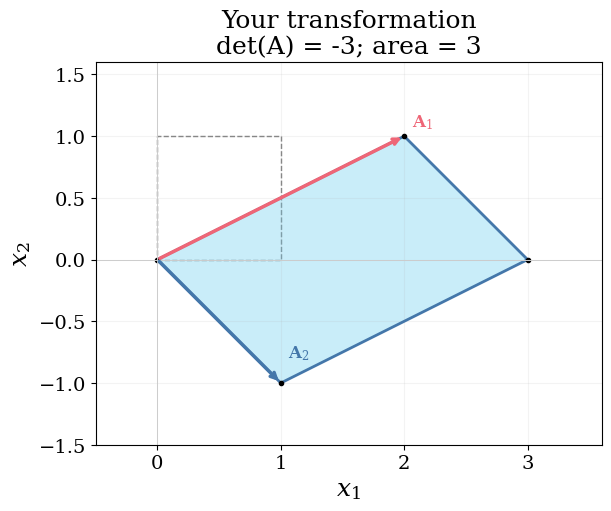

In [4]:
# EDITABLE INPUT: a real 2-by-2 matrix.
A_edit = np.array([[2., 1.], [1., -1.]])
a, b = A_edit[0]
c, d = A_edit[1]
print('ad - bc:', a*d - b*c)
print('det(A): ', np.linalg.det(A_edit))
print('|det(A)|:', abs(np.linalg.det(A_edit)))
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
plot_area_action(A_edit, 'Your transformation', ax)
plt.show()

## 2. Track row operations exactly

Each operation below starts from the **same** matrix. Predict its effect before running the cell. Distinguish the determinant of the changed matrix from the determinant of the original matrix.

Original


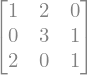

determinant: 7
Swap rows 1 and 2


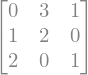

determinant: -7
Multiply row 2 by -3


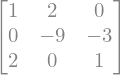

determinant: -21
Add 5 times row 1 to row 3


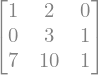

determinant: 7


In [5]:
A_exact = Matrix([[1, 2, 0], [0, 3, 1], [2, 0, 1]])
swapped = A_exact.copy()
swapped.row_swap(0, 1)
scaled = A_exact.copy()
scaled[1, :] = -3 * scaled[1, :]
replaced = A_exact.copy()
replaced[2, :] = replaced[2, :] + 5 * replaced[0, :]

for name, changed in [('Original', A_exact), ('Swap rows 1 and 2', swapped),
                      ('Multiply row 2 by -3', scaled),
                      ('Add 5 times row 1 to row 3', replaced)]:
    print(name)
    show_mat(changed)
    print('determinant:', changed.det())
assert swapped.det() == -A_exact.det()
assert scaled.det() == -3*A_exact.det()
assert replaced.det() == A_exact.det()

### Recover the original determinant after elimination

Follow a new example, separate from the deck's in-class exercise. There is one swap and two row replacements. No pivot row is normalized.

Original matrix:


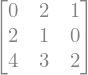

Swap rows 1 and 2:


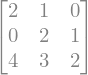

Subtract twice row 1 from row 3:


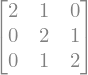

Subtract half of row 2 from row 3:


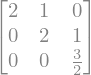

Diagonal product: 6
Original determinant, correcting for one swap: -6


In [6]:
A_elimination = Matrix([[0, 2, 1], [2, 1, 0], [4, 3, 2]])
U_exact = A_elimination.copy()
print('Original matrix:')
show_mat(U_exact)
U_exact.row_swap(0, 1)
print('Swap rows 1 and 2:')
show_mat(U_exact)
U_exact[2, :] = U_exact[2, :] - 2*U_exact[0, :]
print('Subtract twice row 1 from row 3:')
show_mat(U_exact)
U_exact[2, :] = U_exact[2, :] - sp.Rational(1, 2)*U_exact[1, :]
print('Subtract half of row 2 from row 3:')
show_mat(U_exact)
diagonal_product = sp.prod(U_exact.diagonal())
recovered = -diagonal_product
print('Diagonal product:', diagonal_product)
print('Original determinant, correcting for one swap:', recovered)
assert U_exact.is_upper
assert recovered == A_elimination.det() == -6

## 3. Read the determinant from PLU

Return to the deck's worked example. SciPy uses $\mathsf{A}=\mathsf{P}\mathsf{L}\mathsf{U}$, with unit diagonal in $\mathsf{L}$. Inspect all three factors, then compare the determinant obtained from them with the exact value.

For square matrices of the same size, the determinant of a product is the product of the determinants. Thus

$$
\det(\mathsf{A})=\det(\mathsf{P})\det(\mathsf{L})\det(\mathsf{U})
=(-1)^s\prod_{j=1}^n u_{jj}.
$$

Here $s$ is the number of row swaps in the factorization. Starting from the identity, each swap changes the determinant's sign, so $\det(\mathsf{P})=(-1)^s$: $+1$ for an even number of swaps and $-1$ for an odd number. Also, $\det(\mathsf{L})=1$ because its diagonal entries are all one.

The code first checks $\det(\mathsf{P})$ exactly with SymPy. To compute the sign directly from SciPy's packed factorization, count the indices `i` for which `piv[i] != i`: step `i` swaps row `i` with row `piv[i]`. The pivot array records successive swaps, not the final row order. In this example there are two swaps, so $s=2$ and $\det(\mathsf{P})=1$. Only the parity of the swap count matters.


If only $\mathsf{P}$ is given, read its permutation from the columns: a $1$ in row $i$ of column $j$ means $j\mapsto i$. Follow these arrows to find disjoint cycles, including fixed indices as length-one cycles. A cycle of length $k$ has sign $(-1)^{k-1}$, so with $c$ cycles on $n$ indices, $\det(\mathsf{P})=(-1)^{n-c}$. There is no need to perform the swaps. For the displayed $\mathsf{P}$, $1\mapsto2\mapsto3\mapsto1$ is one length-three cycle, giving $\det(\mathsf{P})=(-1)^2=1$.


A, P, L, U (numerical factors):


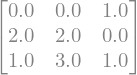

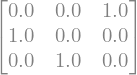

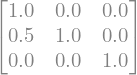

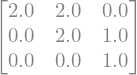

det(P): 1
Diagonal of U: [2. 2. 1.]
det(P) times diagonal product: 4.0
Exact determinant: 4
Pivot history (zero-based): [1 2 2]
Number of row swaps: 2
Determinant from packed LU: 4.0


In [7]:
A_plu_exact = Matrix([[0, 0, 1], [2, 2, 0], [1, 3, 1]])
A_plu = np.array(A_plu_exact, dtype=float)
P, L, U = lu(A_plu)
print('A, P, L, U (numerical factors):')
show_mat(A_plu, P, L, U)
# P contains exact zeros and ones; compute its sign exactly for display.
permutation_sign = int(Matrix(P.astype(int)).det())
det_from_plu = permutation_sign * np.prod(np.diag(U))
print('det(P):', permutation_sign)
print('Diagonal of U:', np.diag(U))
print('det(P) times diagonal product:', det_from_plu)
print('Exact determinant:', A_plu_exact.det())
assert np.allclose(A_plu, P @ L @ U)
assert np.allclose(np.diag(L), 1)
assert np.isclose(det_from_plu, float(A_plu_exact.det()))

# The packed interface records successive zero-based row swaps, not a
# final permutation vector. Count the steps that actually exchange rows.
packed, piv = lu_factor(A_plu)
swap_count = np.count_nonzero(piv != np.arange(len(piv)))
det_from_packed = (-1)**int(swap_count) * np.prod(np.diag(packed))
print('Pivot history (zero-based):', piv)
print('Number of row swaps:', swap_count)
print('Determinant from packed LU:', det_from_packed)
assert np.isclose(det_from_packed, det_from_plu)

## 4. Test products, inverses, and collapse

Predict the sign of a composition of two orientation-reversing transformations. The rightmost matrix acts first. Changing order may change the matrix even when the determinant stays the same.

A, B, B A, A B:


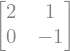

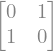

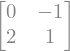

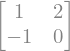

det(A), det(B), det(B A): -2 -1 2
A B equals B A: False
det(A inverse): -1/2
A singular matrix C and a nonzero collapsed direction z:


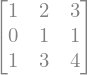

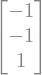

det(C): 0


In [8]:
A_product = Matrix([[2, 1], [0, -1]])
B_product = Matrix([[0, 1], [1, 0]])
print('A, B, B A, A B:')
show_mat(A_product, B_product, B_product*A_product, A_product*B_product)
print('det(A), det(B), det(B A):',
      A_product.det(), B_product.det(), (B_product*A_product).det())
print('A B equals B A:', A_product*B_product == B_product*A_product)
print('det(A inverse):', A_product.inv().det())
assert (B_product*A_product).det() == B_product.det()*A_product.det()
assert A_product.inv().det() == 1/A_product.det()

C = Matrix([[1, 2, 3], [0, 1, 1], [1, 3, 4]])
z = C.nullspace()[0]
print('A singular matrix C and a nonzero collapsed direction z:')
show_mat(C, z, C*z)
print('det(C):', C.det())
assert C.det() == 0 and z != sp.zeros(3, 1) and C*z == sp.zeros(3, 1)

### Preview: multiply eigenvalues, including repetitions

Use exact computation to check the deck's preview. Include every eigenvalue with its algebraic multiplicity. The quarter-turn has complex eigenvalues; the repeated-eigenvalue example need not have a basis of eigenvectors.

In [9]:
for name, A_eigen in {
    'Triangular': Matrix([[2, 1, 0], [0, -3, 2], [0, 0, 4]]),
    'Quarter-turn': Matrix([[0, -1], [1, 0]]),
    'Repeated eigenvalue': Matrix([[2, 1], [0, 2]]),
}.items():
    eigenvalues = A_eigen.eigenvals()  # eigenvalue -> algebraic multiplicity
    eigen_product = sp.prod(value**multiplicity
                            for value, multiplicity in eigenvalues.items())
    print(name)
    print('Eigenvalues and multiplicities:', eigenvalues)
    print('Product:', eigen_product, '; determinant:', A_eigen.det())
    assert sp.simplify(eigen_product - A_eigen.det()) == 0

Triangular
Eigenvalues and multiplicities: {4: 1, -3: 1, 2: 1}
Product: -24 ; determinant: -24
Quarter-turn
Eigenvalues and multiplicities: {-I: 1, I: 1}
Product: 1 ; determinant: 1
Repeated eigenvalue
Eigenvalues and multiplicities: {2: 2}
Product: 4 ; determinant: 4


## 5. Investigate numerical scale

A small determinant alone does not diagnose a nearly singular matrix. Compare two examples below. The **2-norm condition number** compares the largest and smallest directional stretch factors; a large value signals sensitivity in some directions. For these diagonal matrices, inspect the diagonal to see that ratio directly.

Predict which example has a tiny determinant but treats all directions equally, and which has determinant one but very unequal stretches.

In [10]:
numerical_examples = {
    'Small uniform scaling': 0.01*np.eye(8),
    'Unequal directional scaling': np.diag([1.e8, 1.e-8]),
}
for name, A_numeric in numerical_examples.items():
    print(f'{name}: det = {np.linalg.det(A_numeric):.3g}; '
          f'condition number = {np.linalg.cond(A_numeric):.3g}')
print('Uniform scaling has condition number 1 despite a tiny determinant.')
print('The second matrix has determinant 1 but condition number 10^16.')

Small uniform scaling: det = 1e-16; condition number = 1
Unequal directional scaling: det = 1; condition number = 1e+16
Uniform scaling has condition number 1 despite a tiny determinant.
The second matrix has determinant 1 but condition number 10^16.


### Avoid losing the determinant to underflow or overflow

`numpy.linalg.slogdet` returns the sign of the **determinant** and the natural logarithm of its **absolute value**, separately. It avoids forming a product whose magnitude is outside the floating-point range. It does not fix ill-conditioning or restore lost input precision.

For $\mathsf{A}=c\mathsf{I}_{n}$ with $c\ne0$, compare its output with the exact structural prediction $\log|\det(\mathsf{A})|=n\log|c|$. Do not exponentiate the result when the magnitude itself is outside the representable range.

In [11]:
n = 2
for c in [1.e-200, 1.e200, -1.e-200]:
    A_log = c*np.eye(n)
    # This experiment deliberately exceeds the floating-point range.
    with np.errstate(over='ignore', under='ignore'):
        direct = np.linalg.det(A_log)
    sign, log_absolute_determinant = np.linalg.slogdet(A_log)
    predicted_log = n*np.log(abs(c))
    print(f'c={c:g}, n={n}: det={direct:g}, sign={sign:g}, '
          f'log|det|={log_absolute_determinant:.6f}')
    assert np.isclose(log_absolute_determinant, predicted_log)
    assert sign == np.sign(c)**n

# Odd dimension gives a negative determinant for negative uniform scaling.
sign, log_absolute_determinant = np.linalg.slogdet(-1.e-200*np.eye(3))
print(f'Negative scaling in dimension 3: sign={sign:g}, '
      f'log|det|={log_absolute_determinant:.6f}')
assert sign == -1

with np.errstate(divide='ignore', invalid='ignore'):
    singular_sign, singular_log = np.linalg.slogdet(np.diag([1., 0.]))
print('Exactly singular diagonal matrix:', singular_sign, singular_log)
assert singular_sign == 0 and np.isneginf(singular_log)

c=1e-200, n=2: det=0, sign=1, log|det|=-921.034037
c=1e+200, n=2: det=inf, sign=1, log|det|=921.034037
c=-1e-200, n=2: det=0, sign=1, log|det|=-921.034037
Negative scaling in dimension 3: sign=-1, log|det|=-1381.551056
Exactly singular diagonal matrix: 0.0 -inf


## 6. Your experiments

1. In the editable geometry cell, construct two matrices with determinant $-3$ but different shapes. Explain what the determinant captures and what it leaves out.
2. Adapt the row-operation example to multiply **every** row by 2. For a $3\times3$ matrix, predict the total determinant multiplier before computing it.
3. Replace `A_plu_exact` with another nonsingular integer matrix. Compare the exact determinant, the PLU result, and the swap count from the packed interface.
4. Try a $3\times3$ diagonal transformation with one negative diagonal entry. Predict the volume scale and orientation, then verify with SymPy. Repeat with two negative entries.
5. Change the dimension and scalar in the logarithmic determinant experiment. Explain why a negative scalar can produce either determinant sign.

Return to the deck's **Big Ideas**: use the absolute value for volume scaling, the determinant sign for orientation, and elimination for computation. To solve a system, use a solve or factorization routine rather than determinant formulas.

In [12]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 6.4 sec.
